## 1. Structure & Guidelines

The most important thing to do is define your problem statement. This will be your nexus and will help you choose the dataset. Ideally this is the problem that you work on for the rest of the project. Since this is a big decision, you can change the problem statement and the dataset in the next assignment but no changes after that.

### Where to look for a dataset
There are too many sources for me to name all of them. **Kaggle** is the most popular. To search you can just use google or **Google Dataset Search** specifically. A lot of universities have their datasets available, like the one I use in my example below, which can be a great resource too. 


### EDA Study
Here are some mandatory material to help you get a basic understanding:
- https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
- https://www.youtube.com/watch?v=9m4n2xVzk9o

The sky is the limit with EDA, use this as a starting point and I expect you to go beyond. For instance I personally love this free book https://jakevdp.github.io/PythonDataScienceHandbook/ that dives deep into data science with python. <br>
This book is entirely in jupyter notebooks for even more code examples: https://allendowney.github.io/ElementsOfDataScience/



## 2. Assignment Questions/Tasks

1) Brainstorm & write down a problem statement<br><br>
**What insights from internship data can help students avoid scams?**
<br><br>
2) Find a Dataset(s) that will help you solve your problem<br><br>
**Data Source: Internship Scam Detection Dataset(Kaggle)**
<br><br>

3) EDA Study: Go through the guides I link above and my example to get different perspective of how to approach EDA
4) Start your EDA by emulating the steps I take below and start forming hypotheses about the dataset and getting insights
5) Use 5 more visualizations or techniques of your choice that I dont use below
6) Write down insights about the dataset and how it relates back to your problem!!<br>

The insights from the fake internship detection dataset are described below.

Insight 1.<br>
Absence of Website or linkedin account is fraud indicators.There is a 40% chance that a posting is fake without a website and LinkedIn account; however, there is only a 19% chance of being fake if company has these.

Insight 2.<br>
Payment required and fake certification are meaningful features. Internships are 70% likely to be fraudulent when payment is required, compared to only 17% when payment is not needed. Fake certificate offers show a similar trend, increasing from about 20% fake proportion without a fake certificate offer to about 52% fake amount when a fake certificate is offered."

Insight 3.<br>
Suspicious email domain is a less important clue. Postings with a suspicious email domain have a 39% chance of being scam while postings without one have only 18% . This indicator is not as strong as payment requirements or fake certificate offers, but it can be a useful signal.

Insight 4.<br>
recruiter_email_type is a red flag. Job postings with free email domains (e.g, gmail.com) account for 39% fake postings, compared to only 18% fake postings with corporate emails.

Insight 5..<br>
A correlation heatmap provides strong indicators. Since fraud_score and trust_signal_score are generated from multiple suspicious features, they cannot be used in a data model. As payment_required and registration_fee are strongly correlated (0.86), only one of them is needed.
Thus, 7 features
1) payment_required (0.37)
2) phishing_language_score (0.28)
3) vague_description_score (0.24) 
4) suspicious_email_domain (0.22)
5) fake_certificate_offer (0.21)
6) linkedin_presence (inversely correlated, -0.21)
7) website_available (inversely correlated, -0.19) 
8) urgency_score (0.14)
9) grammatical_errors(0.11)
10) keyword_spam_score(0.11)
can be used as combined indicators for detecting fake job postings.


## 3. Exploratory Data Analysis

This is the same example from class. I have kept things basic and barebones here so this can serve as a springboard for your analyses. In each step I have added some questions you should ask to get insights into the dataset. The answers to these and other questions that you ask might be through more statistical analysis and visualizations!

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### 1. Data Loading & Quick Overview

In [34]:
#Your dataset here
df = pd.read_csv("fake_internship_detection_dataset.csv") #details here https://archive.ics.uci.edu/dataset/2/adult, click on the import in python button to check it out

In [69]:
# Display first few rows
pd.set_option('display.max_columns', None)
df.describe()
df

,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,website_available,domain_age_months,verification_status,stipend,payment_required,registration_fee,job_description_length,grammatical_errors,vague_description_score,urgency_score,keyword_spam_score,fake_certificate_offer,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026/09/10,ML Engineer,Internship,Remote,Marketing,Berlin,"Russell, Medina and Evans",Startup,23.0,1,1,286,1,43083.0,0,0,2009,1,42,14,15,0,0.3,Free,1,17.6,1,12,28,48.4,51.8,1
1,2020/05/10,UI/UX Designer,Contract,Onsite,Marketing,Bangalore,Hays-White,Startup,12.0,0,1,170,1,26888.0,0,0,1901,1,51,29,14,1,5.1,Free,1,30.2,1,9,27,47.6,75.3,1
2,2021/07/18,UI/UX Designer,Internship,Hybrid,Gaming,Toronto,"Obrien, Gonzalez and Harris",Small,10.0,1,1,130,1,35353.0,0,0,1060,0,0,5,26,0,6.0,Free,1,12.5,0,26,18,98.8,0.0,0
3,2021/02/04,UI/UX Designer,Part-Time,Remote,AI,Berlin,"Martinez, Odonnell and Davidson",Enterprise,33.0,1,1,399,1,23666.0,0,0,1523,3,21,6,30,0,3.8,Corporate,0,24.6,1,20,0,72.2,11.0,0
4,2020/12/31,AI Research Intern,Internship,Onsite,EdTech,Toronto,Garcia-Owens,Small,14.0,0,1,172,1,56479.0,0,0,2203,3,44,0,19,0,7.0,Free,1,30.3,0,16,50,34.4,56.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024/10/18,AI Research Intern,Internship,Onsite,Cybersecurity,London,James-Page,Medium,20.0,1,1,226,1,53937.0,0,0,2233,2,19,71,23,0,10.0,Free,1,9.7,1,43,17,77.2,10.1,0
999996,2018/02/17,AI Research Intern,Part-Time,Hybrid,Software,Berlin,Cannon-Stevens,Small,18.0,0,0,220,1,48166.0,0,0,300,2,52,24,24,0,3.9,Free,1,20.9,0,0,29,41.9,91.4,1
999997,2026/01/15,Backend Developer,Full-Time,Onsite,E-Commerce,London,Bryan-Taylor,Startup,38.0,1,1,474,1,36342.0,0,0,824,3,0,8,32,0,2.5,Corporate,0,51.2,0,0,39,84.4,0.0,0
999998,2018/05/09,Marketing Intern,Internship,Remote,Marketing,New York,"Ramirez, Chaney and James",Startup,9.0,1,1,119,0,38769.0,0,0,820,5,37,54,12,0,1.0,Free,1,26.3,1,14,9,60.0,37.1,0


In [36]:
# Confirm which rows/columns are null
df.isnull().sum()

posting_date                         0
internship_title                     0
employment_type                      0
work_mode                            0
industry                             0
location                             0
company_name                         0
company_size                         0
company_age                      10000
linkedin_presence                    0
website_available                    0
domain_age_months                    0
verification_status                  0
stipend                          10000
payment_required                     0
registration_fee                     0
job_description_length               0
grammatical_errors                   0
vague_description_score              0
urgency_score                        0
keyword_spam_score                   0
fake_certificate_offer               0
recruiter_experience_years           0
recruiter_email_type                 0
suspicious_email_domain              0
recruiter_response_time_h

#### Questions to ponder: 

1. Does the data match your expectations or do you think you might need more information?
2. Do the columns/features align with your problem statement?
3. Any immediate signs of missing or corrupted data? 


### 2. Shape & Features

In [37]:
# Shape : (rows, columns)
print(f"Dataset shape: {df.shape}")

# Display all column names
print("\nFeature Names:")
print(df.columns.tolist())

Dataset shape: (1000000, 32)

Feature Names:
['posting_date', 'internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_name', 'company_size', 'company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'recruiter_email_type', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score', 'fraud_score', 'is_fake_posting']


#### Questions to ponder: 

1. Is the data large enough for the analysis?
2. Are there any duplicate columns, or columns with similar information or ones that need re-naming? (I renamed some columns in my dataset below)

In [38]:
#replacing "-" with "_"
#df.columns = df.columns.str.replace("-","_")
#df.columns

### 3. Data Types & Missing Values

In [39]:
# understanding the datatypes
df.dtypes

posting_date                         str
internship_title                     str
employment_type                      str
work_mode                            str
industry                             str
location                             str
company_name                         str
company_size                         str
company_age                      float64
linkedin_presence                  int64
website_available                  int64
domain_age_months                  int64
verification_status                int64
stipend                          float64
payment_required                   int64
registration_fee                   int64
job_description_length             int64
grammatical_errors                 int64
vague_description_score            int64
urgency_score                      int64
keyword_spam_score                 int64
fake_certificate_offer             int64
recruiter_experience_years       float64
recruiter_email_type                 str
suspicious_email

In [40]:
# Check missing values
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
posting_date                         0
internship_title                     0
employment_type                      0
work_mode                            0
industry                             0
location                             0
company_name                         0
company_size                         0
company_age                      10000
linkedin_presence                    0
website_available                    0
domain_age_months                    0
verification_status                  0
stipend                          10000
payment_required                     0
registration_fee                     0
job_description_length               0
grammatical_errors                   0
vague_description_score              0
urgency_score                        0
keyword_spam_score                   0
fake_certificate_offer               0
recruiter_experience_years           0
recruiter_email_type                 0
suspicious_email_domain              0
re

In [41]:
#check if missing data could be an insight and of itself.
df[df["company_age"].isna()]["is_fake_posting"].value_counts(normalize=True)

is_fake_posting
0    0.78
1    0.22
Name: proportion, dtype: float64

In [42]:
df[df["stipend"].isna()]["is_fake_posting"].value_counts(normalize=True)

is_fake_posting
0    0.7804
1    0.2196
Name: proportion, dtype: float64

In [43]:
df[df["trust_signal_score"].isna()]["is_fake_posting"].value_counts(normalize=True)


is_fake_posting
0    0.7762
1    0.2238
Name: proportion, dtype: float64

In [44]:
#perform imputation in missing values
df['company_age'] = df['company_age'].fillna(df['company_age'].median())
df['stipend'] = df['stipend'].fillna(df['stipend'].median())
df['trust_signal_score'] = df['trust_signal_score'].fillna(df['trust_signal_score'].median())

In [45]:
#check again if there is any missing values
df.isnull().sum()

posting_date                     0
internship_title                 0
employment_type                  0
work_mode                        0
industry                         0
location                         0
company_name                     0
company_size                     0
company_age                      0
linkedin_presence                0
website_available                0
domain_age_months                0
verification_status              0
stipend                          0
payment_required                 0
registration_fee                 0
job_description_length           0
grammatical_errors               0
vague_description_score          0
urgency_score                    0
keyword_spam_score               0
fake_certificate_offer           0
recruiter_experience_years       0
recruiter_email_type             0
suspicious_email_domain          0
recruiter_response_time_hours    0
social_media_presence            0
emotional_manipulation_score     0
phishing_language_sc

#### Questions to ponder: 

- Should we drop or impute missing values?
- Could missing data be an insight in and of itself?

### 4. Summary Statistics & Outlier Detection

In [46]:
#Summary Stats
df.describe()

,company_age,linkedin_presence,website_available,domain_age_months,verification_status,stipend,payment_required,registration_fee,job_description_length,grammatical_errors,vague_description_score,urgency_score,keyword_spam_score,fake_certificate_offer,recruiter_experience_years,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,20.000172,0.800764,0.849597,239.541209,0.699713,35065.376224,0.099905,252.083069,1799.538324,2.998825,30.132072,40.047191,25.573860,0.07983,5.052660,0.250567,18.180467,0.749800,25.563839,20.749288,56.559289,34.012258,0.221958
std,11.195680,0.399426,0.357466,135.737891,0.458383,14755.725096,0.299873,881.467489,598.563156,1.731828,18.814980,23.612605,18.116422,0.27103,2.871692,0.433340,9.611051,0.433128,18.129998,15.884219,16.280329,21.371783,0.415563
min,1.000000,0.000000,0.000000,1.000000,0.000000,2000.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,1.000000,1.000000,123.000000,0.000000,24959.000000,0.000000,0.000000,1395.000000,2.000000,16.000000,23.000000,11.000000,0.00000,3.000000,0.000000,11.200000,0.000000,11.000000,7.000000,45.700000,18.100000,0.000000
50%,20.000000,1.000000,1.000000,240.000000,1.000000,34984.000000,0.000000,0.000000,1799.000000,3.000000,30.000000,39.000000,25.000000,0.00000,5.000000,0.000000,18.000000,1.000000,24.000000,19.000000,56.900000,32.300000,0.000000
75%,30.000000,1.000000,1.000000,356.000000,1.000000,45008.000000,0.000000,0.000000,2203.000000,4.000000,43.000000,56.000000,38.000000,0.00000,7.000000,1.000000,24.800000,1.000000,38.000000,32.000000,67.800000,47.800000,0.000000
max,39.000000,1.000000,1.000000,500.000000,1.000000,110428.000000,1.000000,4999.000000,5000.000000,14.000000,100.000000,100.000000,100.000000,1.00000,19.600000,1.000000,63.900000,1.000000,100.000000,100.000000,100.000000,100.000000,1.000000


#### Question to ponder
- Did you expect outliers? 
- Which features have unusually high or low values? What do they tell us about the data?
- Are there any suspicious patterns or extreme outliers?
- Do we need to drop or transform these outliers?

In [47]:
df.dtypes

posting_date                         str
internship_title                     str
employment_type                      str
work_mode                            str
industry                             str
location                             str
company_name                         str
company_size                         str
company_age                      float64
linkedin_presence                  int64
website_available                  int64
domain_age_months                  int64
verification_status                int64
stipend                          float64
payment_required                   int64
registration_fee                   int64
job_description_length             int64
grammatical_errors                 int64
vague_description_score            int64
urgency_score                      int64
keyword_spam_score                 int64
fake_certificate_offer             int64
recruiter_experience_years       float64
recruiter_email_type                 str
suspicious_email

In [48]:
df["stipend"].value_counts().head(20)

stipend
2000.0     13752
34984.0    10040
32771.0       45
36198.0       44
38288.0       44
40089.0       44
36995.0       44
34240.0       44
34117.0       43
33726.0       43
42014.0       43
35242.0       43
31356.0       43
32156.0       43
35511.0       43
37053.0       43
28146.0       42
30871.0       42
33013.0       42
34382.0       42
Name: count, dtype: int64

### 5. Univariate Analysis

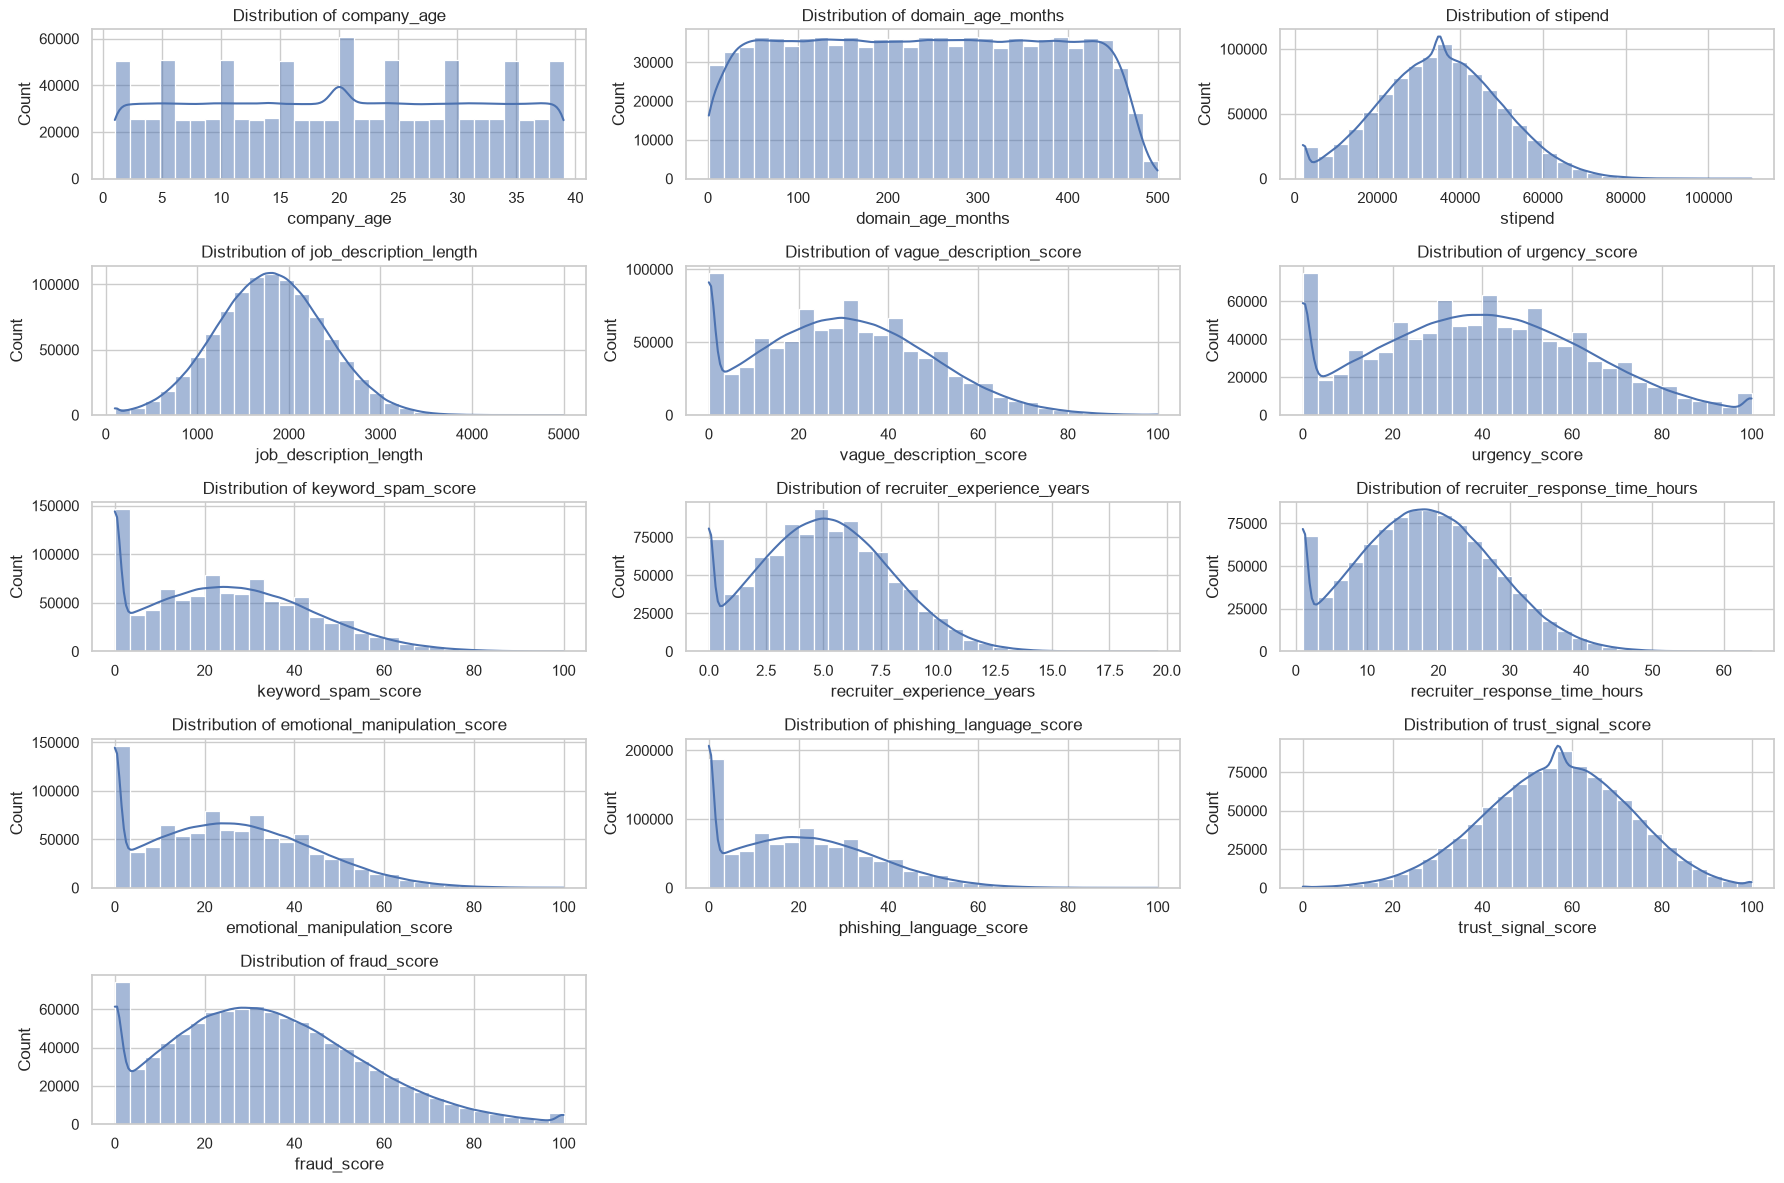

In [49]:
# Define features for visualization (Choosing the numerical features)
num_features = ['company_age',
    'domain_age_months',
    'stipend',
    'job_description_length',
    'vague_description_score',
    'urgency_score',
    'keyword_spam_score',
    'recruiter_experience_years',
    'recruiter_response_time_hours',
    'emotional_manipulation_score',
    'phishing_language_score',
    'trust_signal_score',
    'fraud_score']

# Create a 8x3 grid for visualization
fig, ax = plt.subplots(5, 3, figsize=(18, 12))

# Iterate over features and plot
for i, feature in enumerate(num_features):
    row, col = divmod(i, 3)
    sns.histplot(df[feature], kde=True, bins=30, ax=ax[row, col])
    ax[row, col].set_title(f'Distribution of {feature}')

# Hide any unused empty subplot slots
for j in range(i + 1, 5 * 3):
    row, col = divmod(j, 3)
    fig.delaxes(ax[row, col])

plt.tight_layout()
plt.show()

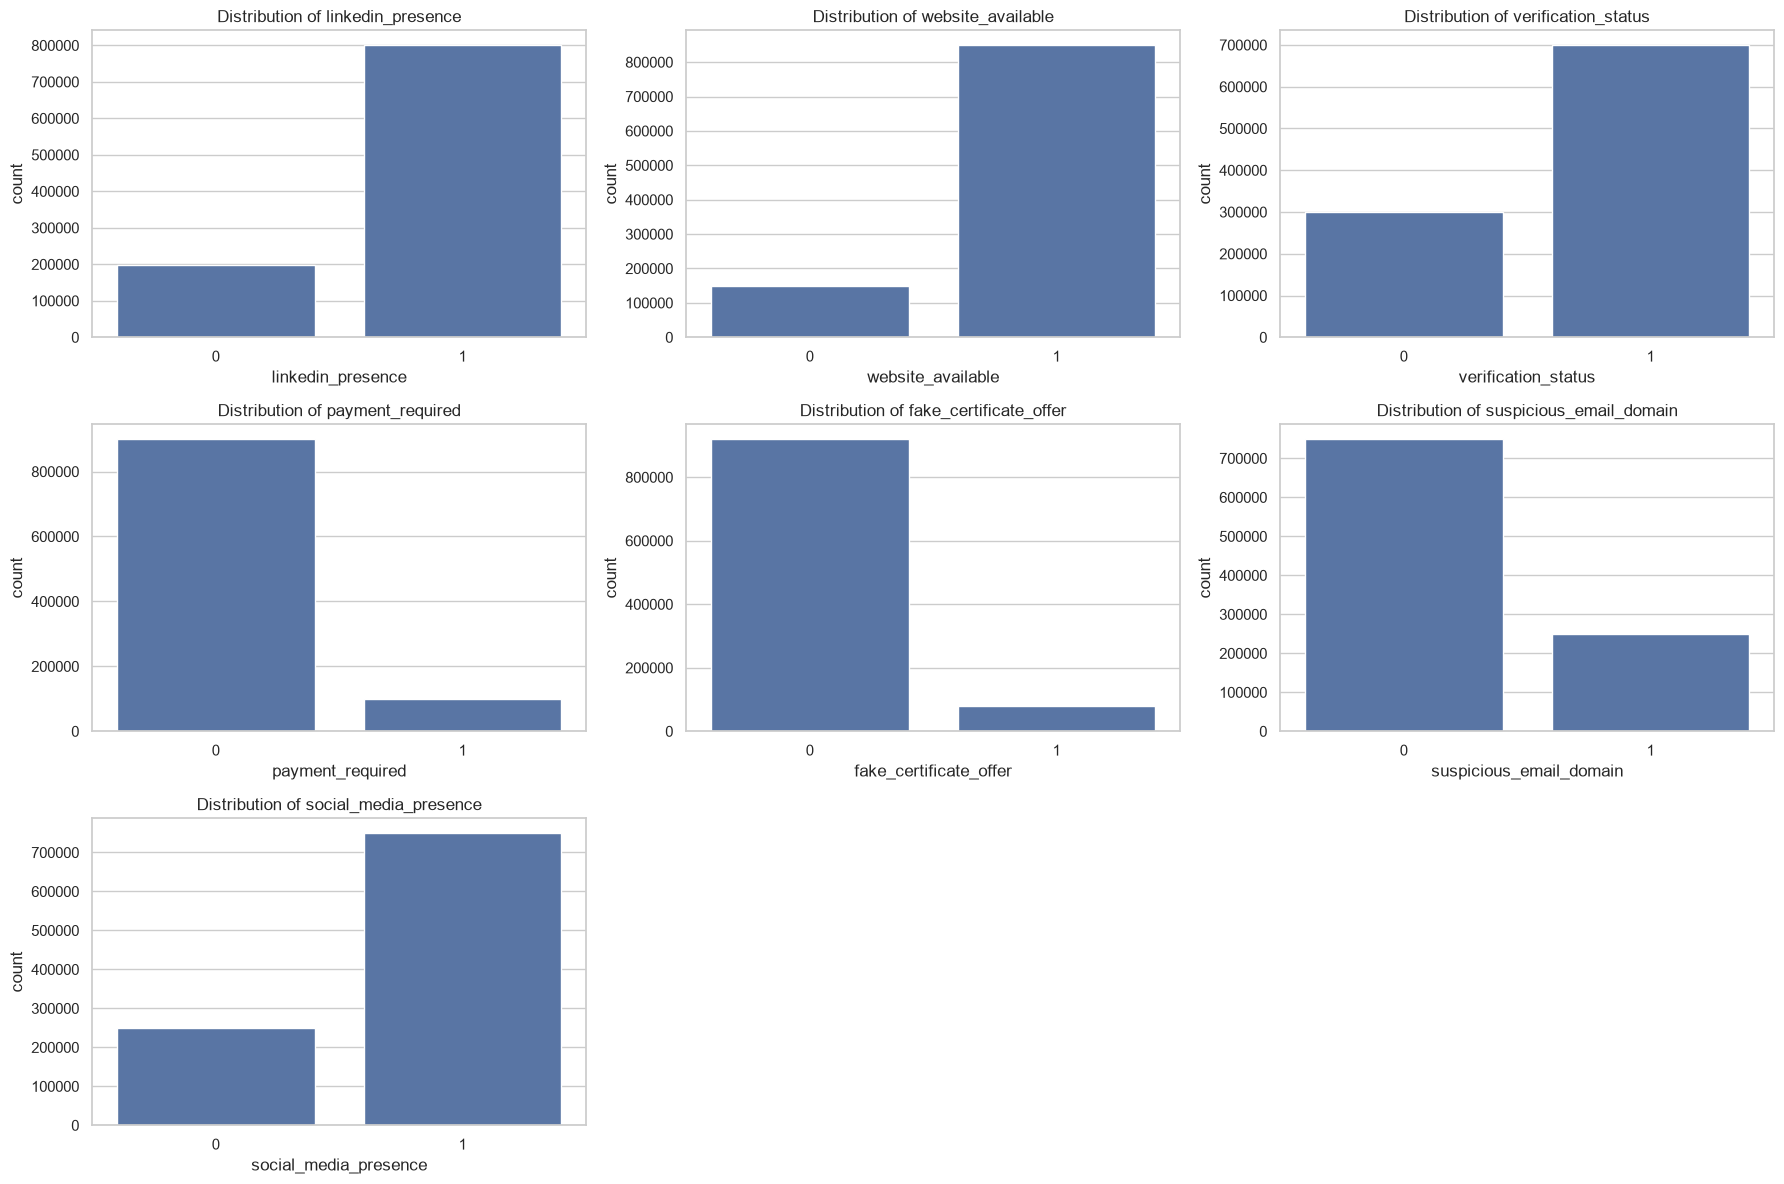

In [50]:
# Define features for visualization (Choosing the binary features)
bi_features = ['linkedin_presence', 'website_available', 'verification_status', 
                    'payment_required', 'fake_certificate_offer', 'suspicious_email_domain', 
                    'social_media_presence']


# Create a 8x3 grid for visualization
fig, ax = plt.subplots(3, 3, figsize=(18, 12))

# Iterate over features and plot
for i, feature in enumerate(bi_features):
    row, col = divmod(i, 3)
    sns.countplot(x=df[feature], ax=ax[row, col])
    ax[row, col].set_title(f'Distribution of {feature}')
    
# Hide any unused empty subplot slots
for j in range(i + 1, 3 * 3):
    row, col = divmod(j, 3)
    fig.delaxes(ax[row, col])
    
plt.tight_layout()
plt.show()

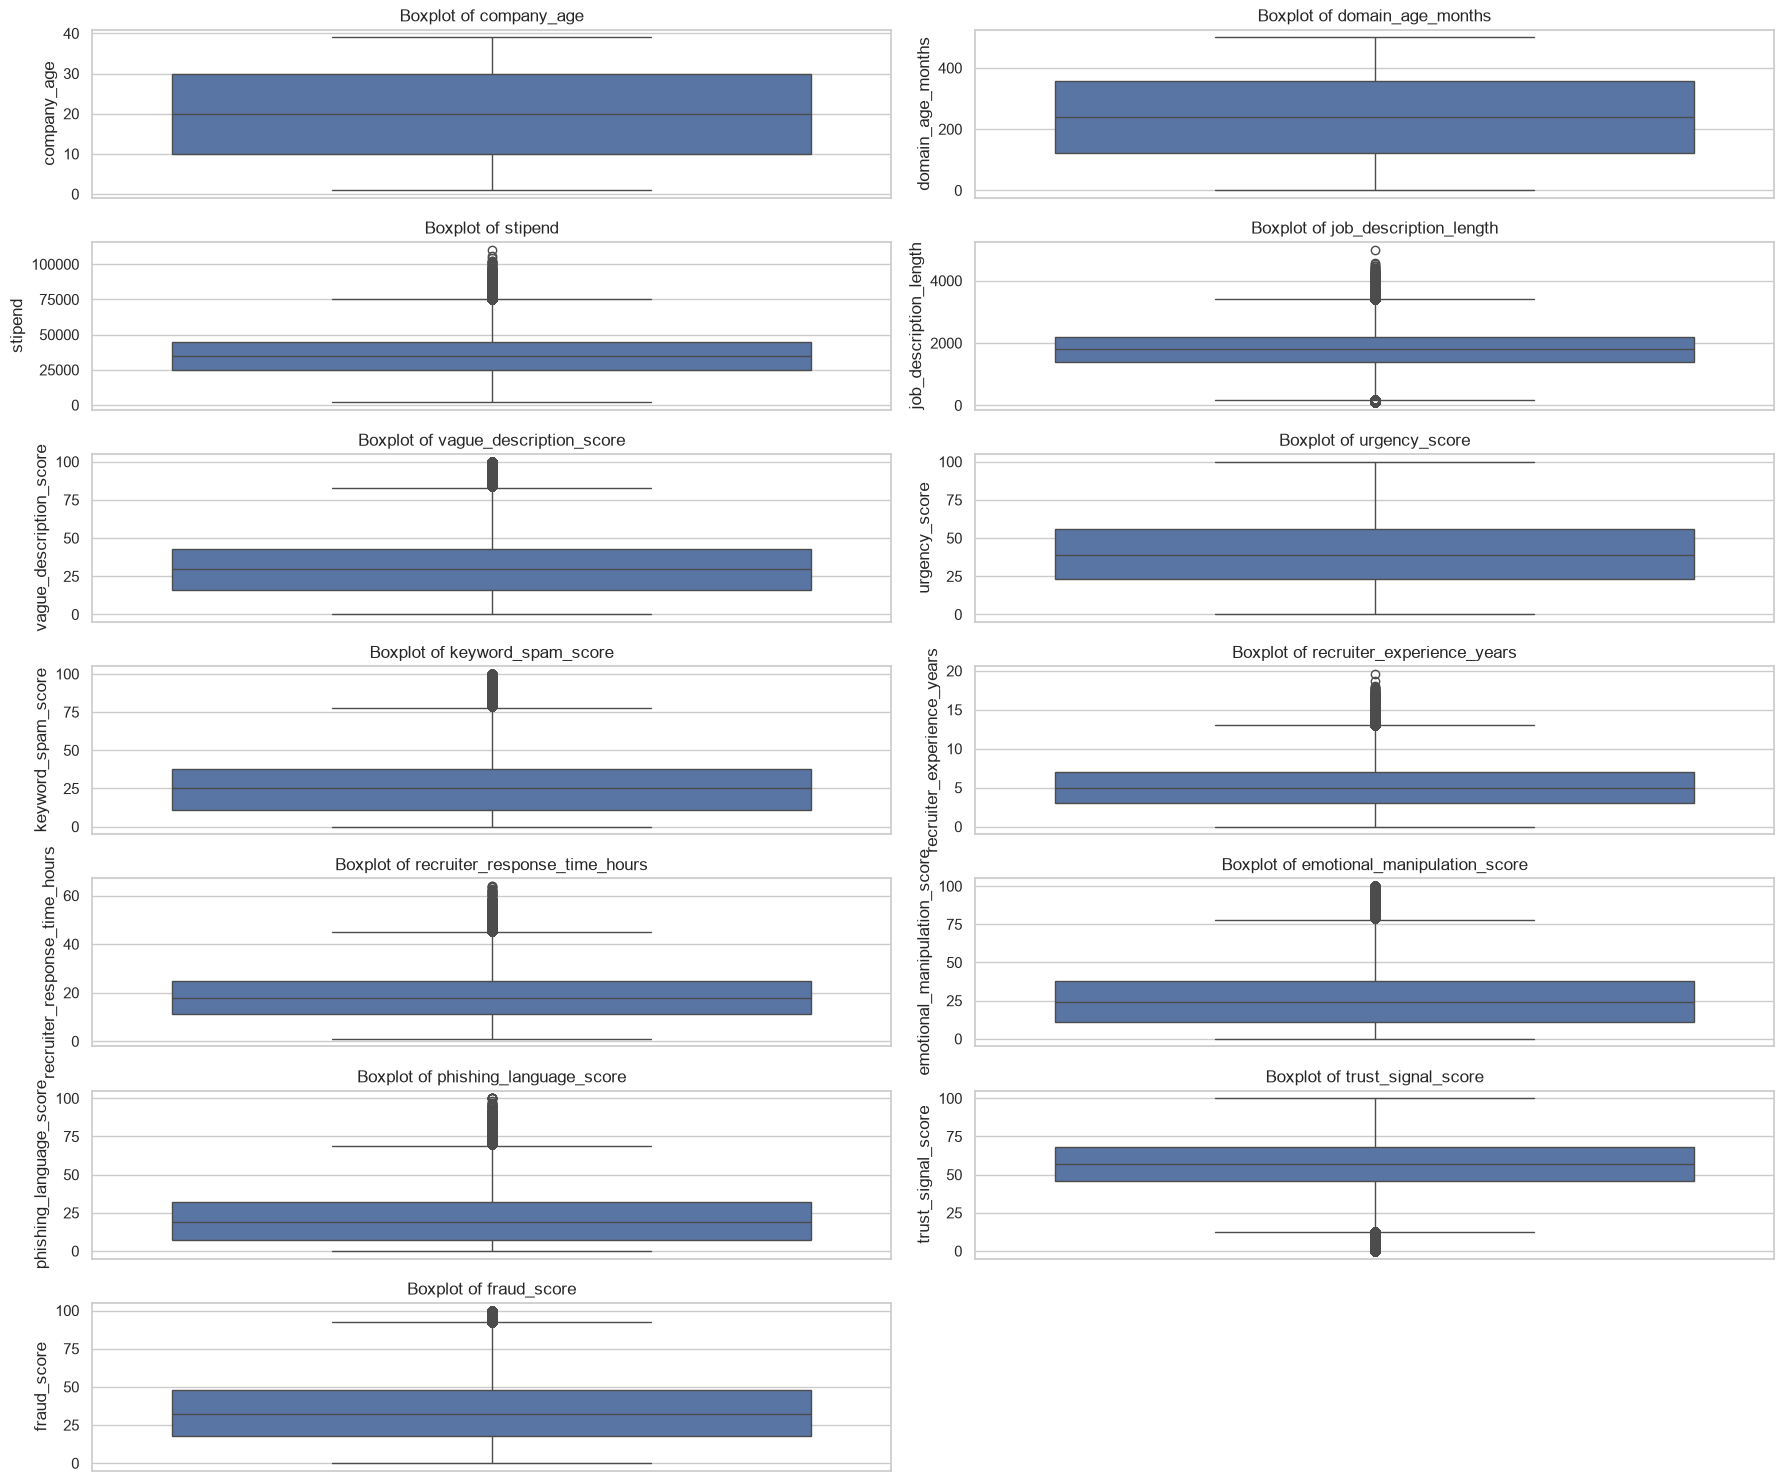

In [51]:
# Create boxplots for numerical variables
fig, ax = plt.subplots(7, 2, figsize=(18, 15))

for i, feature in enumerate(num_features):
    row, col = divmod(i, 2)
    sns.boxplot(y=df[feature], ax=ax[row, col])
    ax[row, col].set_title(f'Boxplot of {feature}')
# Hide any unused empty subplot slots
for j in range(i + 1, 7 * 2):
    row, col = divmod(j, 2)
    fig.delaxes(ax[row, col])

plt.tight_layout()
plt.show()


In [52]:
df.columns

Index(['posting_date', 'internship_title', 'employment_type', 'work_mode',
       'industry', 'location', 'company_name', 'company_size', 'company_age',
       'linkedin_presence', 'website_available', 'domain_age_months',
       'verification_status', 'stipend', 'payment_required',
       'registration_fee', 'job_description_length', 'grammatical_errors',
       'vague_description_score', 'urgency_score', 'keyword_spam_score',
       'fake_certificate_offer', 'recruiter_experience_years',
       'recruiter_email_type', 'suspicious_email_domain',
       'recruiter_response_time_hours', 'social_media_presence',
       'emotional_manipulation_score', 'phishing_language_score',
       'trust_signal_score', 'fraud_score', 'is_fake_posting'],
      dtype='str')

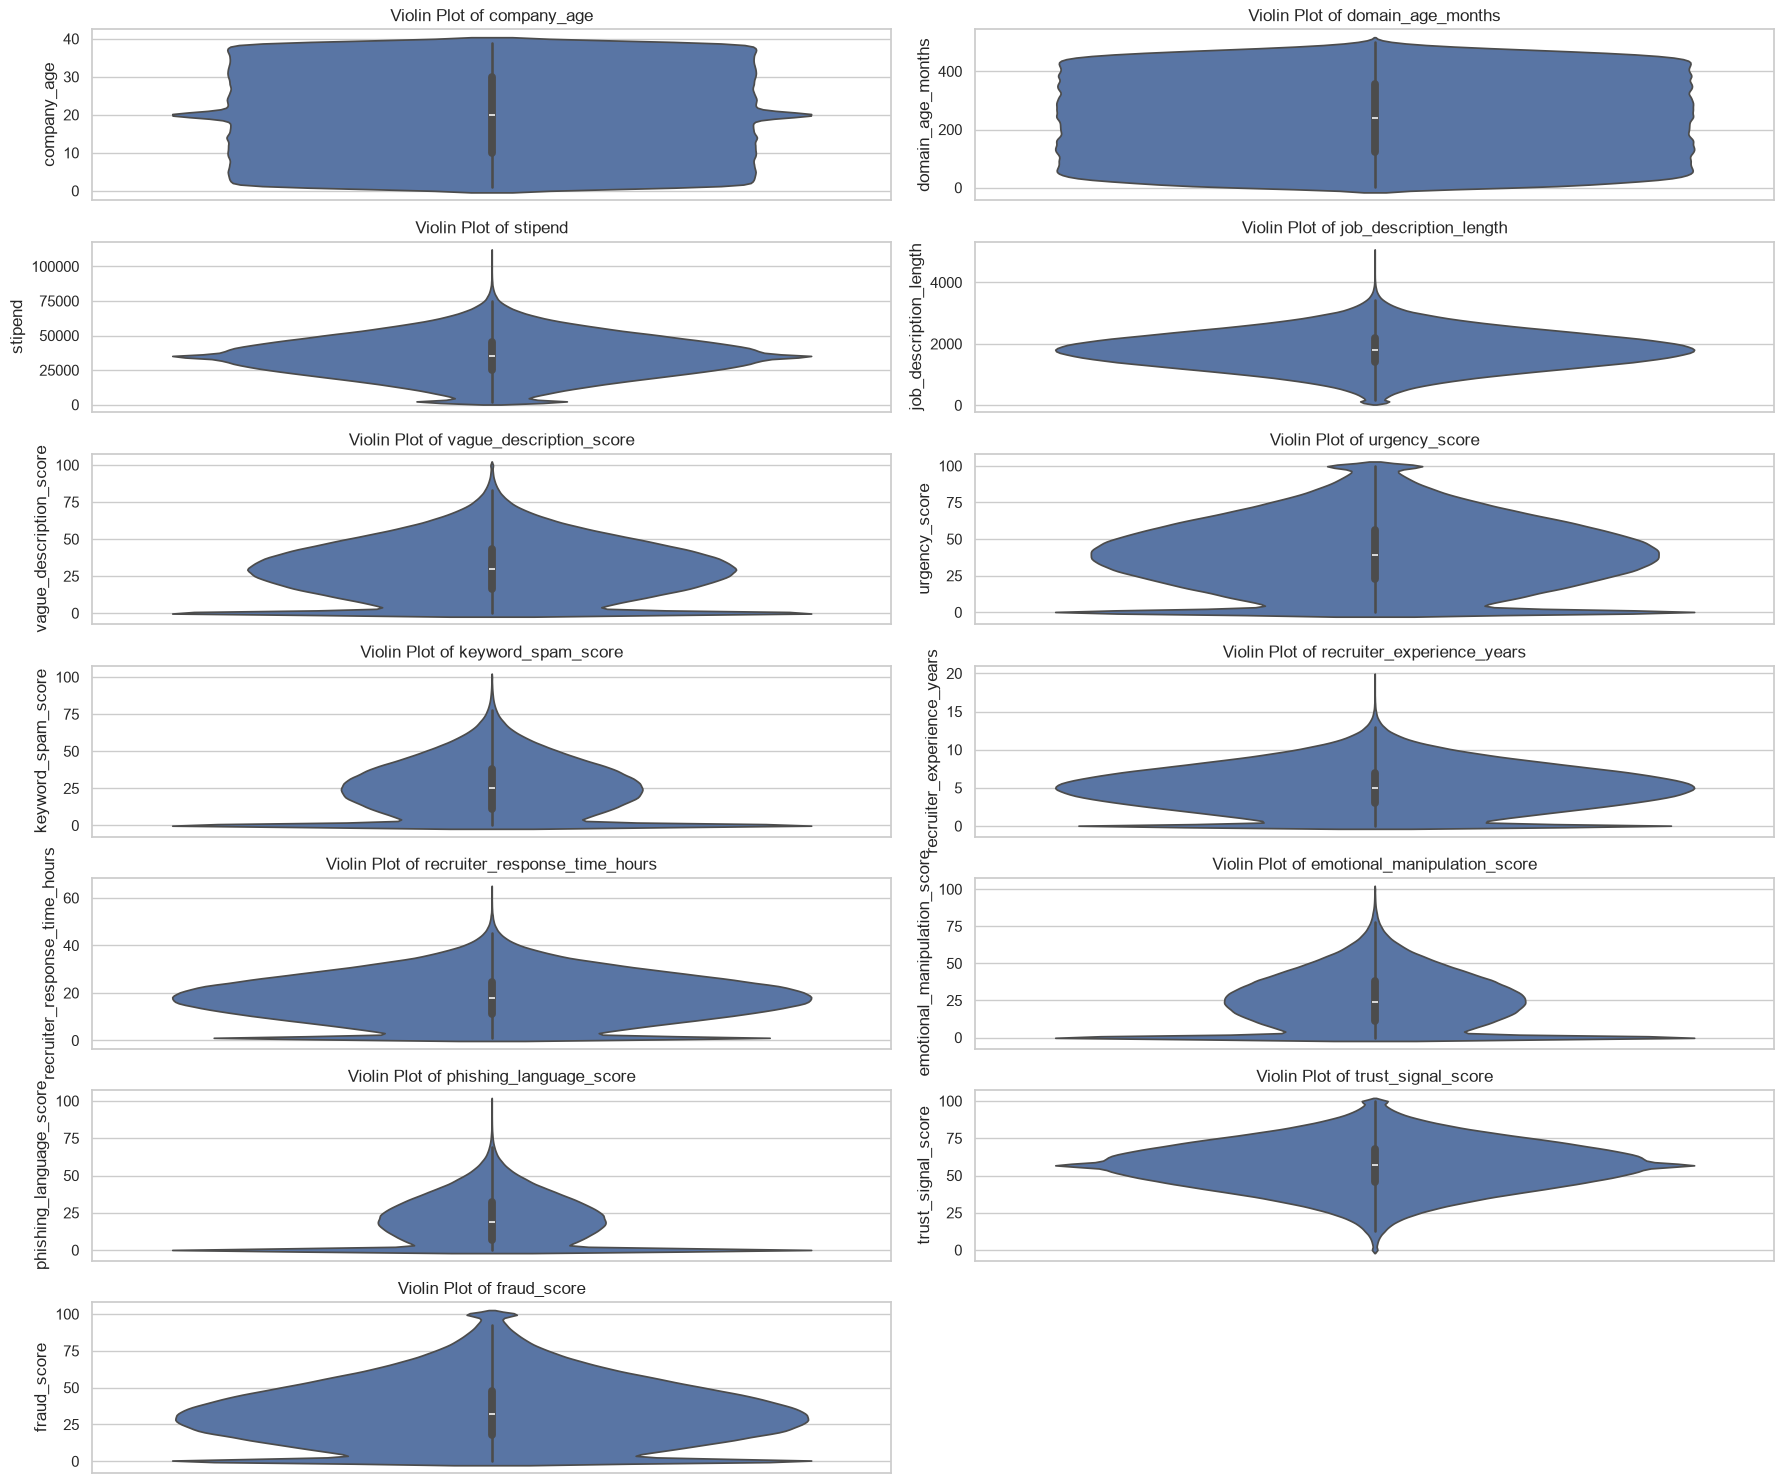

In [53]:
# Create violin plots for numerical variables
fig, ax = plt.subplots(7, 2, figsize=(18, 15))

for i, feature in enumerate(num_features):
    row, col = divmod(i, 2)
    sns.violinplot(y=df[feature], ax=ax[row, col])
    ax[row, col].set_title(f'Violin Plot of {feature}')


# Hide any unused empty subplot slots
for j in range(i + 1, 7 * 2):
    row, col = divmod(j, 2)
    fig.delaxes(ax[row, col])

plt.tight_layout()
plt.show()


In [54]:
df['recruiter_email_type'].unique()

<StringArray>
['Free', 'Corporate']
Length: 2, dtype: str

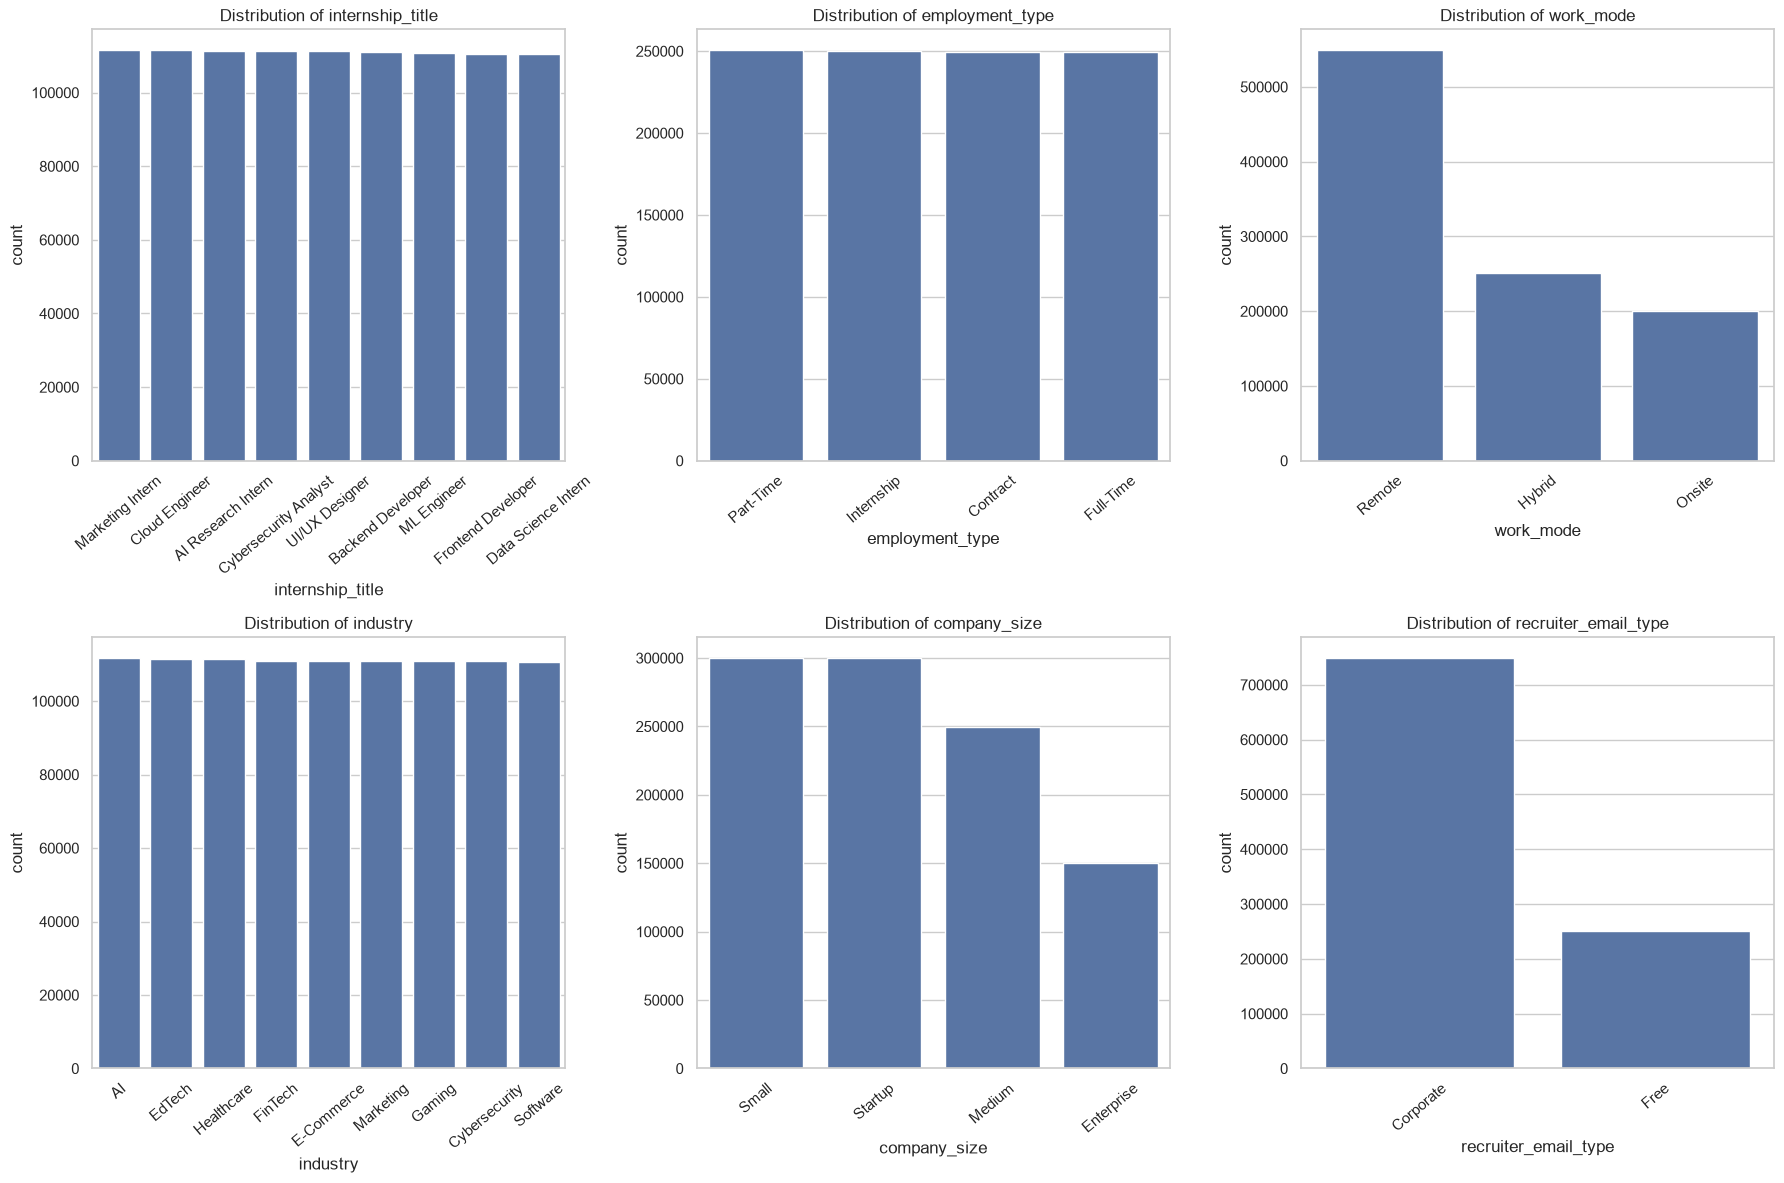

In [55]:
# Define categorical features for visualization
cat_features = ['internship_title',
 'employment_type',
 'work_mode',
 'industry',
 'company_size',
 'recruiter_email_type']

# Create a 2x3 grid for visualization
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

# Iterate over categorical features and plot
for i, feature in enumerate(cat_features):
    row, col = divmod(i, 3)
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index, ax=ax[row, col])
    ax[row, col].set_title(f'Distribution of {feature}')
    ax[row, col].tick_params(axis='x', rotation=40)  # Rotate x-axis labels for better readability
    
plt.tight_layout()
plt.show()

#### Questions to ponder:

- Are the numerical features skewed or roughly normal?
- Which categories dominate in each categorical feature? What does that tell you about each feature? 


### 6. Bivariate Analysis

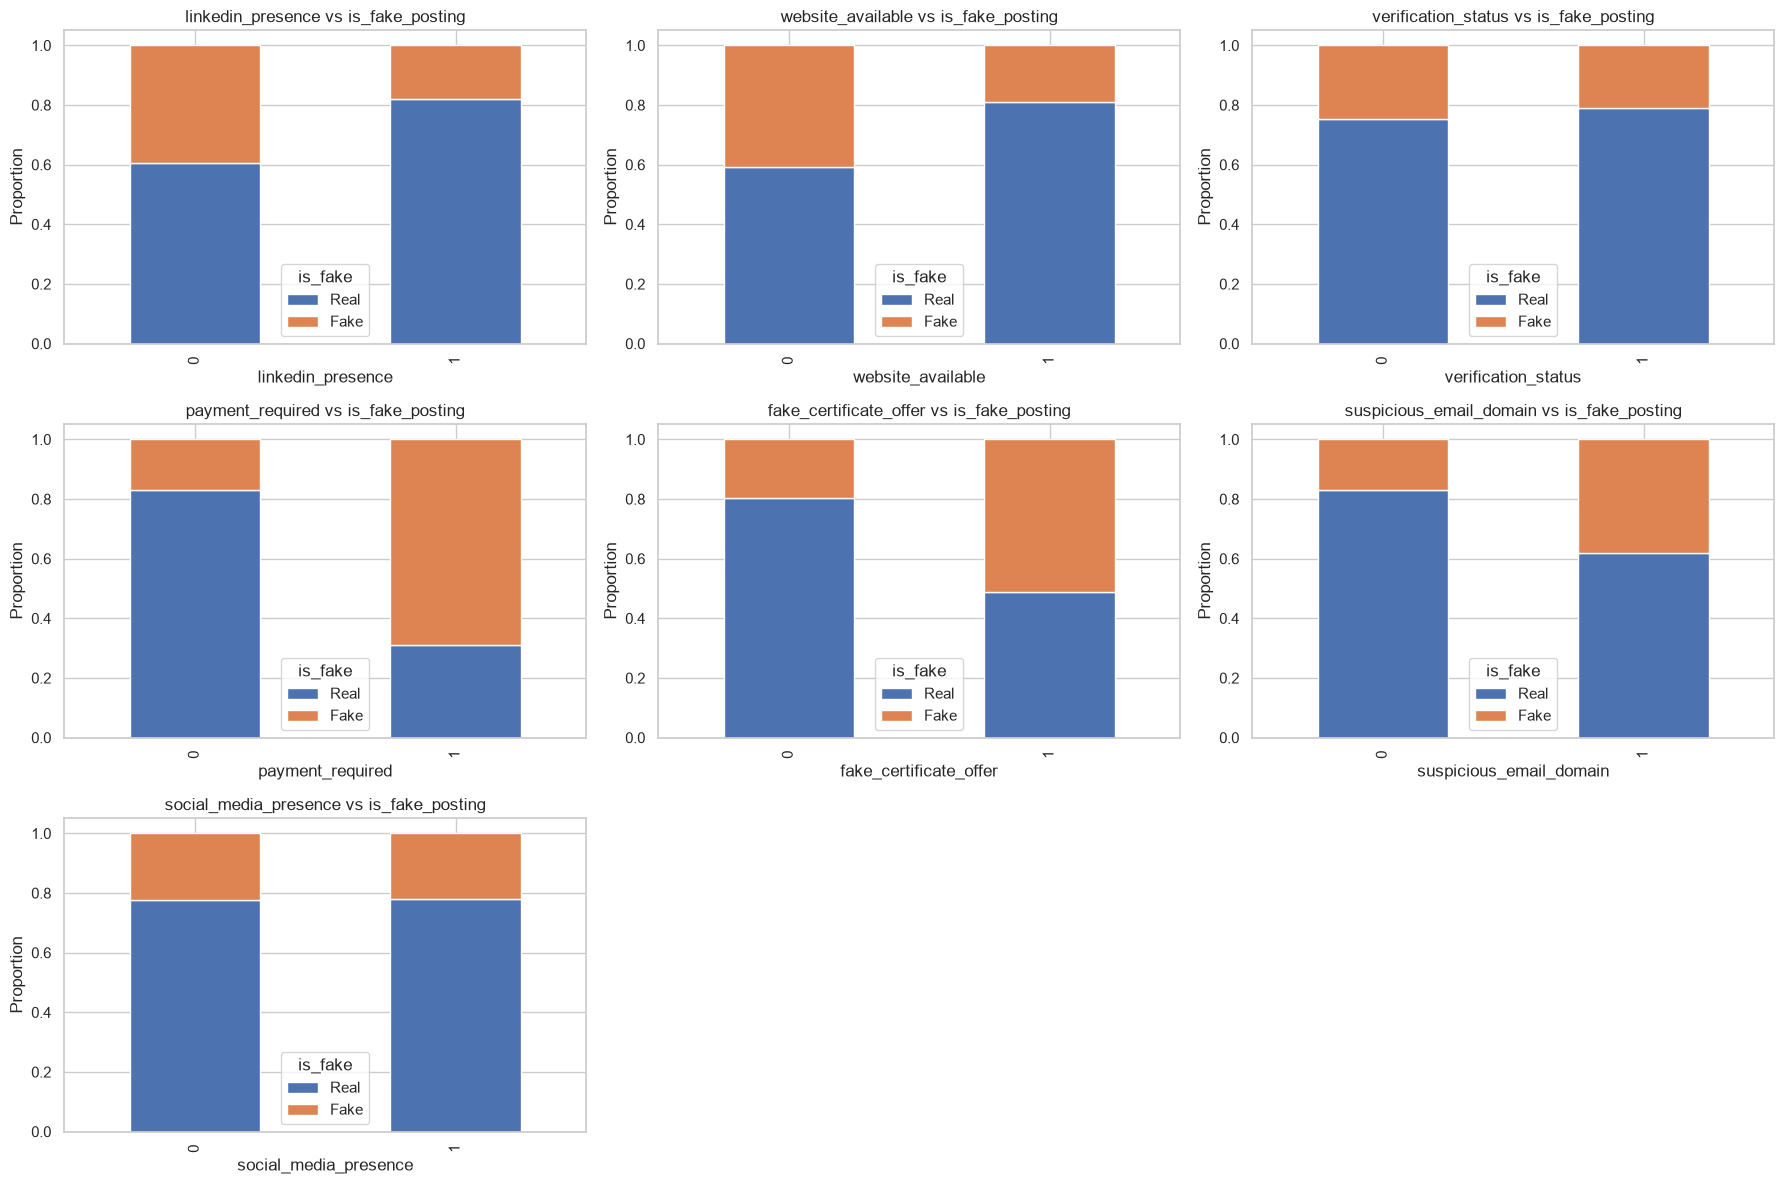

In [56]:
# Create a 3x3 grid for visualization
fig, ax = plt.subplots(3, 3, figsize=(18, 12))

# Iterate over features and plot
for i, feature in enumerate(bi_features):
    row, col = divmod(i, 3)
    ct = pd.crosstab(df[feature], df['is_fake_posting'], normalize='index')
    ct.plot.bar(stacked=True, ax=ax[row, col])
    ax[row, col].set_title(f'{feature} vs is_fake_posting')
    ax[row, col].set_ylabel('Proportion')
    ax[row, col].legend(title='is_fake', labels=['Real', 'Fake'])

# Hide any unused empty subplot slots
for j in range(i + 1, 3 * 3):
    row, col = divmod(j, 3)
    fig.delaxes(ax[row, col])

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

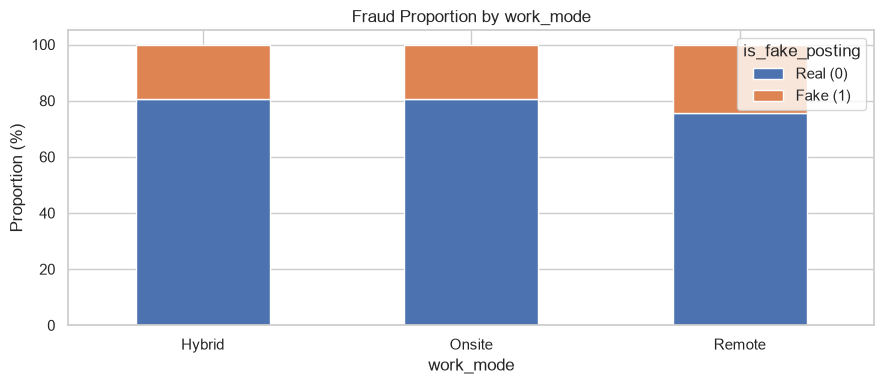

<Figure size 640x480 with 0 Axes>

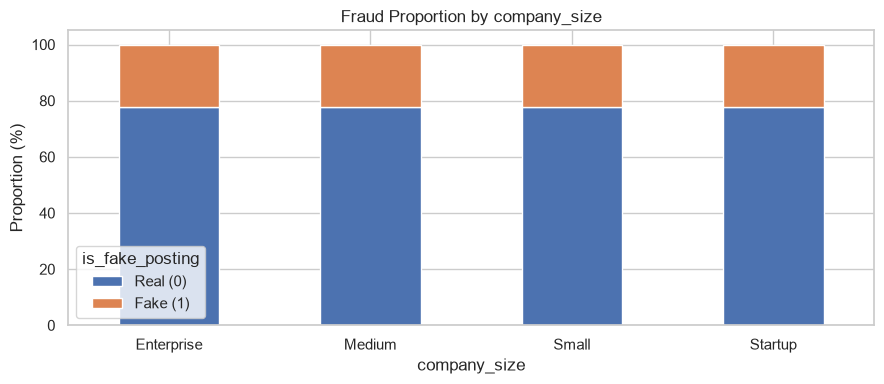

<Figure size 640x480 with 0 Axes>

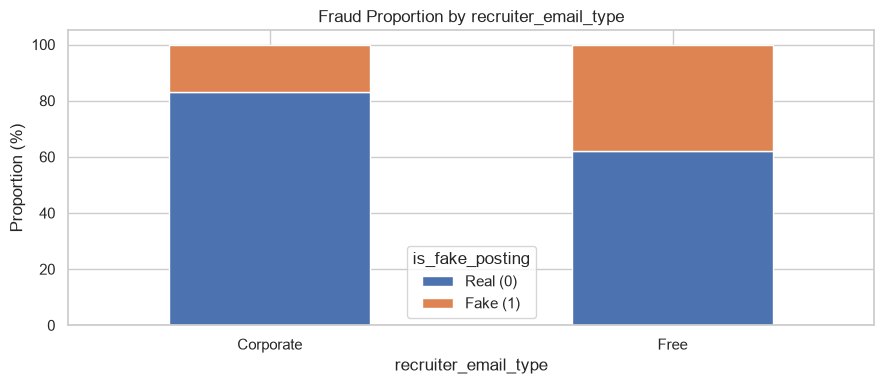

<Figure size 640x480 with 0 Axes>

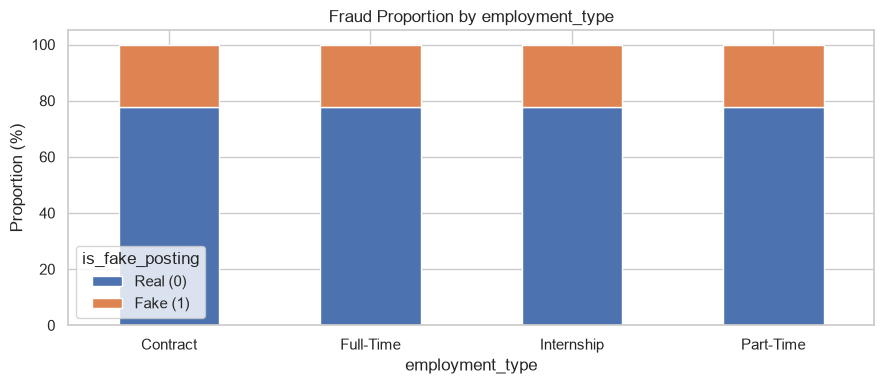

<Figure size 640x480 with 0 Axes>

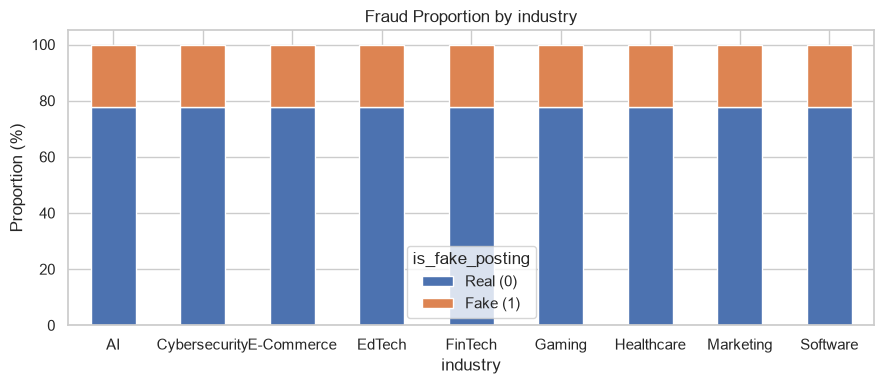

<Figure size 640x480 with 0 Axes>

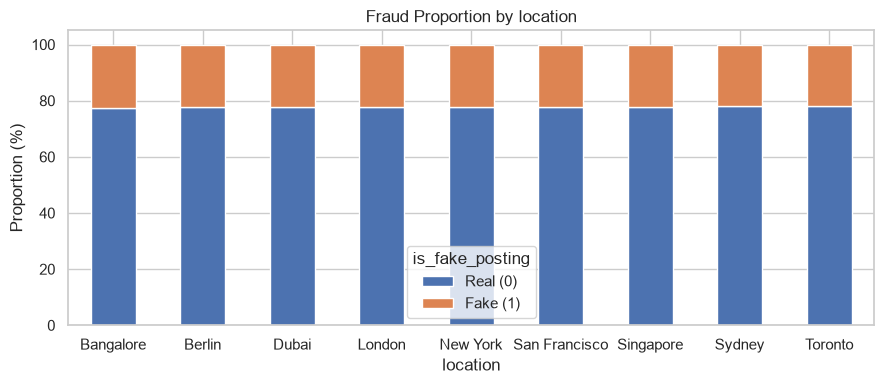

In [74]:
#stacked bar
categorical_cols = ['work_mode', 'company_size', 'recruiter_email_type','employment_type', 'industry', 'location']
target = 'is_fake_posting'

for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    
    plt.figure()  # <- forces a brand new figure each loop
    ct.plot(kind='bar', stacked=True, figsize=(9,4))
    plt.xlabel(col)
    plt.ylabel('Proportion (%)')
    plt.title(f'Fraud Proportion by {col}')
    plt.legend(['Real (0)', 'Fake (1)'], title=target)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

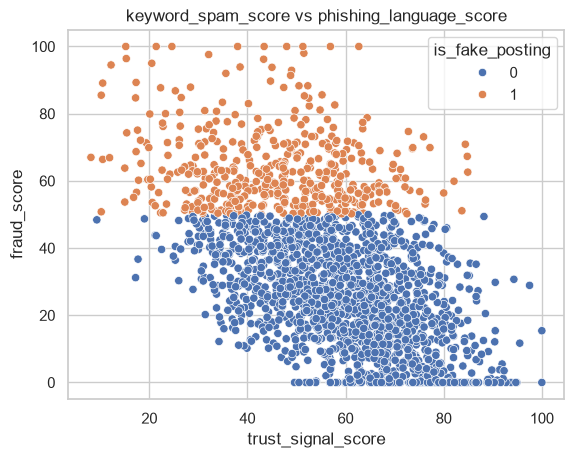

In [58]:
#scatter plot
sns.scatterplot(x='trust_signal_score', y='fraud_score', hue='is_fake_posting', data=df.sample(2000))
plt.title("keyword_spam_score vs phishing_language_score")
plt.show()

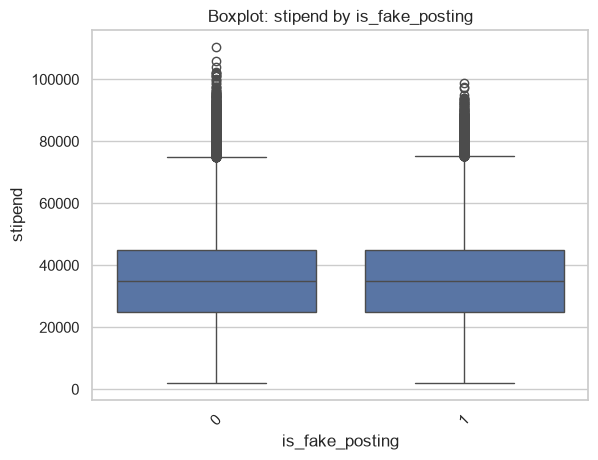

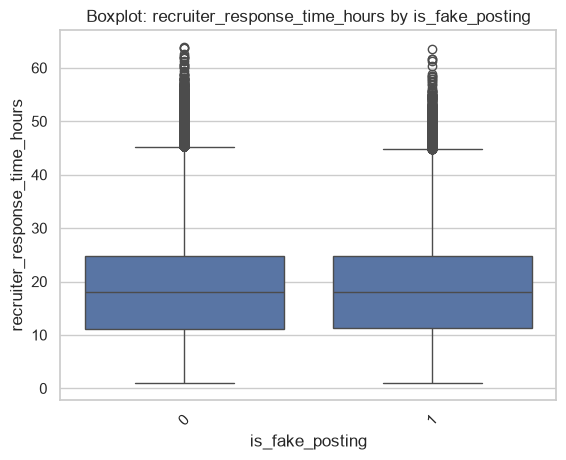

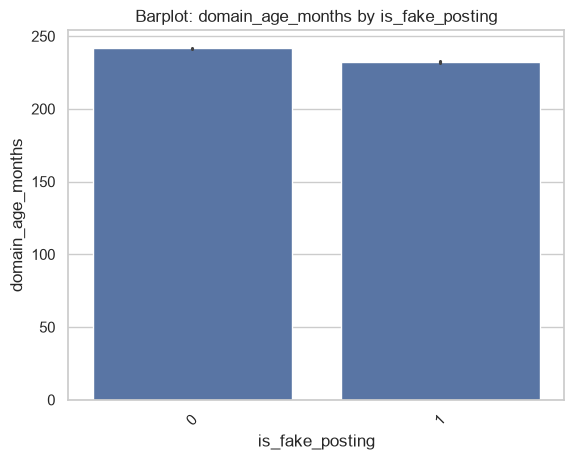

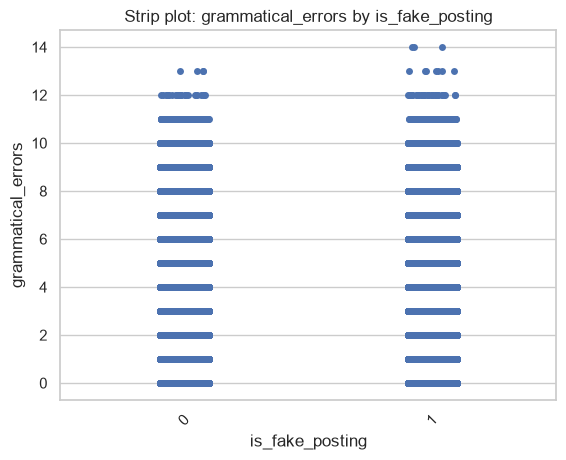

is_fake_posting          0         1
payment_required                    
0                 0.829846  0.170154
1                 0.311316  0.688684


In [59]:
# Box plot for numerical vs. categorical
sns.boxplot(x='is_fake_posting', y='stipend', data=df)
plt.title("Boxplot: stipend by is_fake_posting")
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x='is_fake_posting', y='recruiter_response_time_hours', data=df)
plt.title("Boxplot: recruiter_response_time_hours by is_fake_posting")
plt.xticks(rotation=45)
plt.show()

# Bar plot for numerical vs. categorical
sns.barplot(x='is_fake_posting', y='domain_age_months', data=df)
plt.title("Barplot: domain_age_months by is_fake_posting")
plt.xticks(rotation=45)
plt.show()

#Strip plot for numerical vs. categorical
sns.stripplot(x='is_fake_posting', y='grammatical_errors', data=df)
plt.title("Strip plot: grammatical_errors by is_fake_posting")
plt.xticks(rotation=45)
plt.show()

#Cross Tabulation
print(pd.crosstab(df['payment_required'], df['is_fake_posting'], normalize='index'))



#### Questions to ponder

- Which numerical features are correlated?
- Do certain categories strongly associate with higher or lower numerical values?
- Any visible clusters or patterns in scatter plots?

### 7. Multivariate Analysis

In [60]:
numeric = df.select_dtypes(include=[np.number])
numeric.columns

Index(['company_age', 'linkedin_presence', 'website_available',
       'domain_age_months', 'verification_status', 'stipend',
       'payment_required', 'registration_fee', 'job_description_length',
       'grammatical_errors', 'vague_description_score', 'urgency_score',
       'keyword_spam_score', 'fake_certificate_offer',
       'recruiter_experience_years', 'suspicious_email_domain',
       'recruiter_response_time_hours', 'social_media_presence',
       'emotional_manipulation_score', 'phishing_language_score',
       'trust_signal_score', 'fraud_score', 'is_fake_posting'],
      dtype='str')

In [61]:
correlation = numeric.corr()
print(correlation["is_fake_posting"].sort_values(ascending=False), '\n')

is_fake_posting                  1.000000
fraud_score                      0.763767
payment_required                 0.374175
registration_fee                 0.321503
phishing_language_score          0.278532
vague_description_score          0.243059
suspicious_email_domain          0.219823
fake_certificate_offer           0.206038
urgency_score                    0.141569
grammatical_errors               0.110640
keyword_spam_score               0.110176
recruiter_response_time_hours    0.000430
emotional_manipulation_score    -0.000384
job_description_length          -0.000529
stipend                         -0.000761
recruiter_experience_years      -0.001493
social_media_presence           -0.001540
domain_age_months               -0.029391
company_age                     -0.029603
verification_status             -0.041771
website_available               -0.189424
linkedin_presence               -0.206890
trust_signal_score              -0.384508
Name: is_fake_posting, dtype: floa

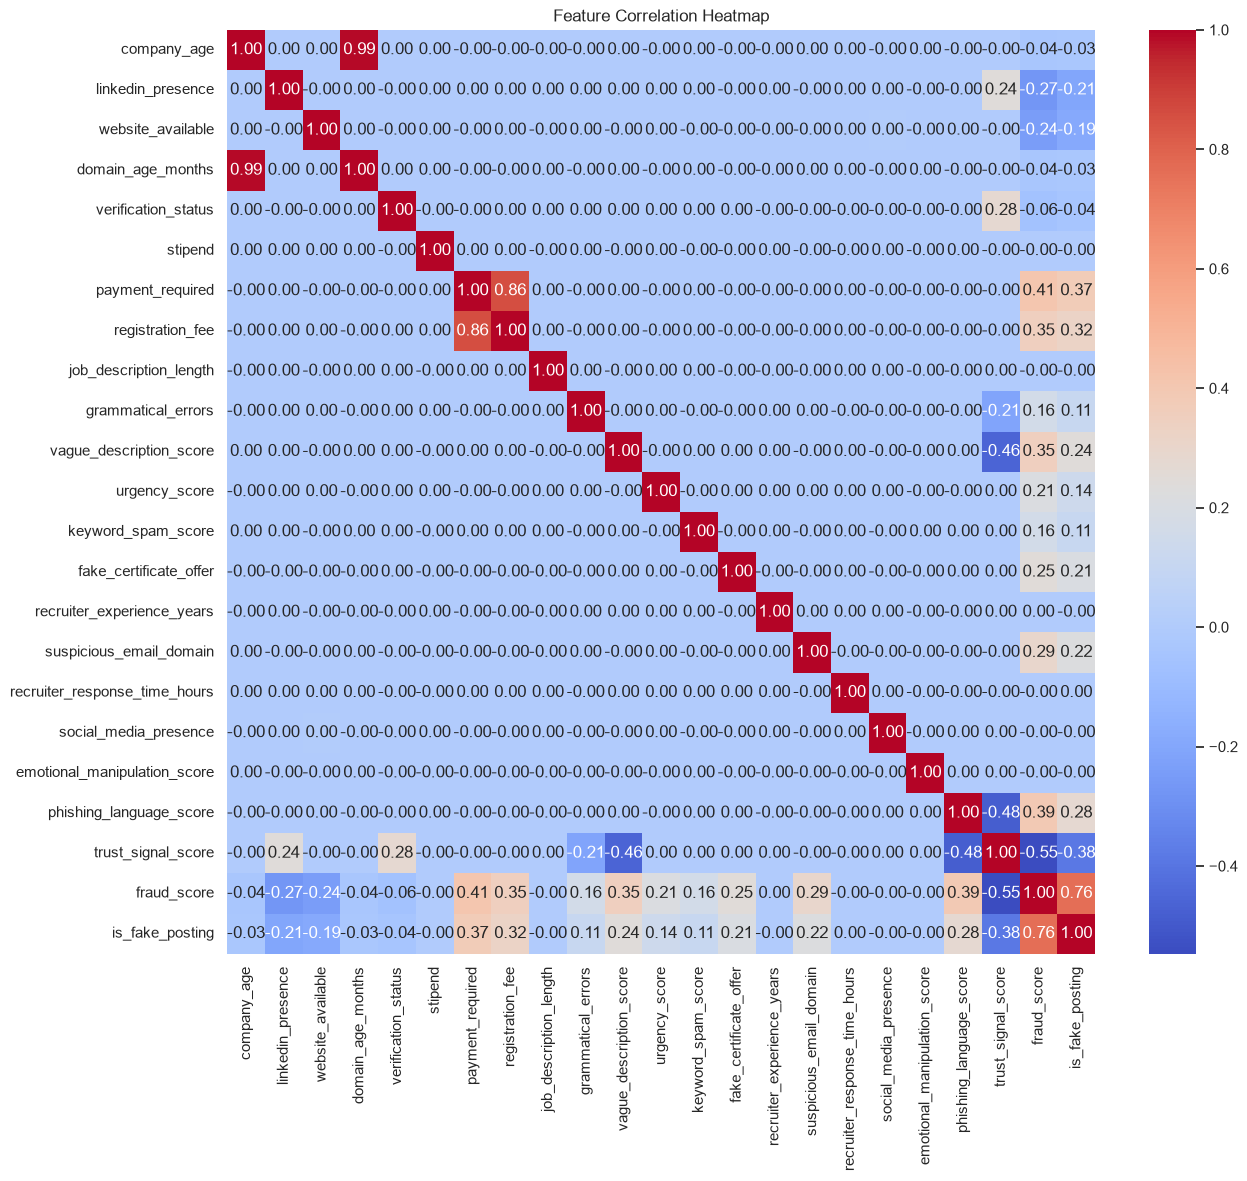

In [62]:
# Create a correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Index(['is_fake_posting', 'fraud_score', 'trust_signal_score',
       'payment_required', 'registration_fee', 'phishing_language_score',
       'vague_description_score', 'suspicious_email_domain',
       'linkedin_presence', 'fake_certificate_offer', 'website_available',
       'urgency_score', 'grammatical_errors', 'keyword_spam_score'],
      dtype='str')


<Axes: >

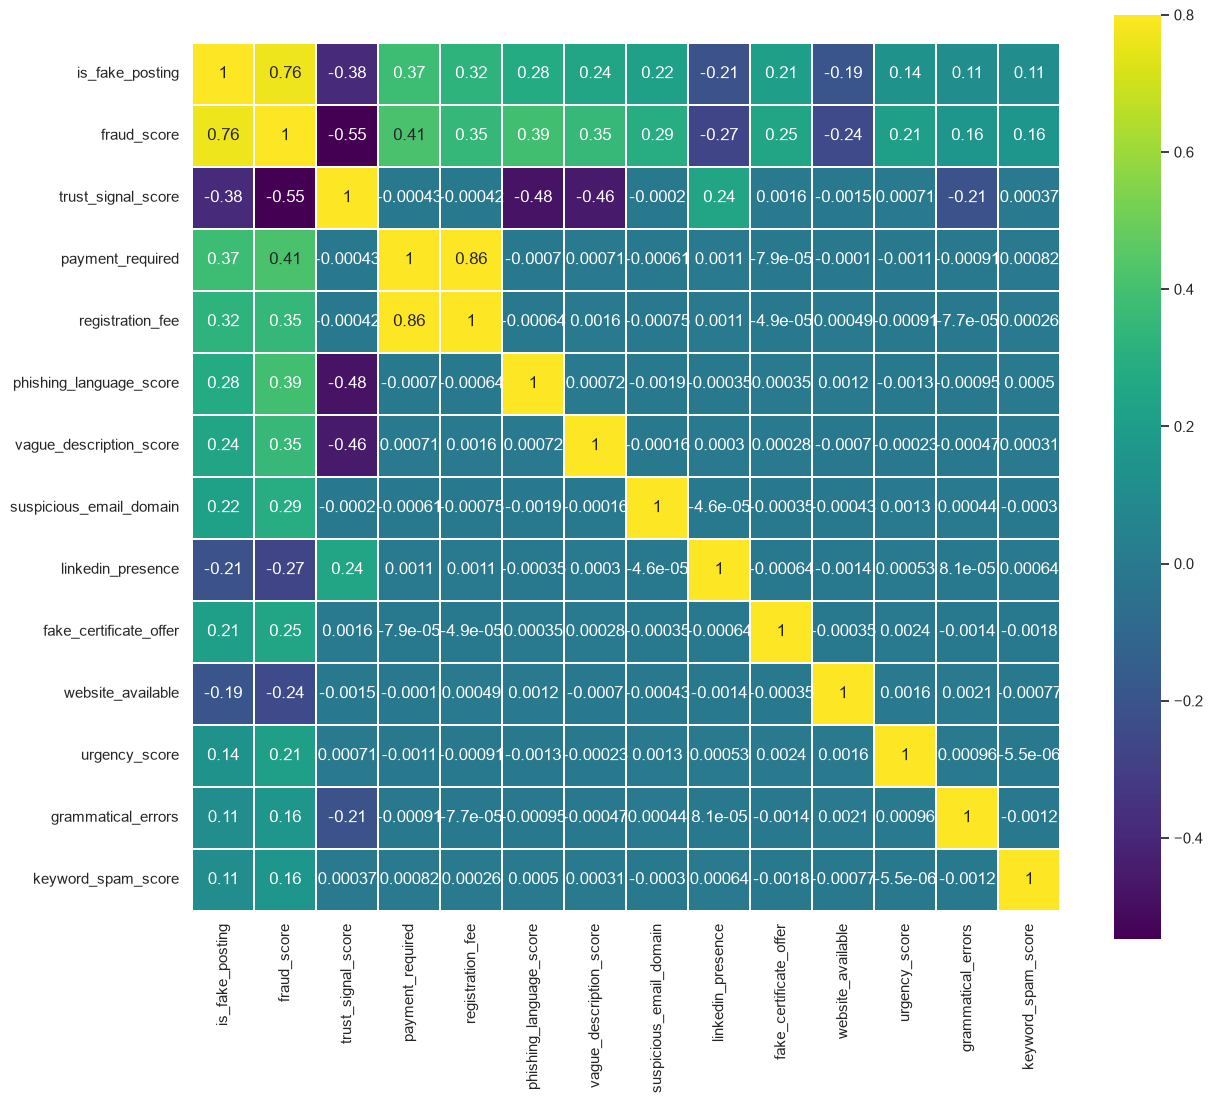

In [68]:
k = 14
cols = correlation['is_fake_posting'].abs().nlargest(k).index
print(cols)
cm = np.corrcoef(df[cols].values.T)
f, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, vmax=.8, linewidths=0.01, square=True, annot=True, cmap='viridis',
            linecolor="white", xticklabels=cols.values, annot_kws={'size': 12}, yticklabels=cols.values)

In [64]:
#compare red flags values between fake and real job postings
df.groupby('is_fake_posting')[['payment_required', 'suspicious_email_domain',
                                  'phishing_language_score', 'vague_description_score']].mean()

,payment_required,suspicious_email_domain,phishing_language_score,vague_description_score
is_fake_posting,,,,
0,0.039975,0.199688,18.386226,27.689492
1,0.309982,0.428914,29.032664,38.694185


#### Questions to ponder

- Which features show strong correlation?
- Should we remove or combine highly correlated features?
- Are there surprising correlations that warrant deeper investigation?

### 8. Next Steps

- Which features appear most important for the problem?
- What data cleaning or transformation steps remain?
- How will these insights guide the next phase (modeling, reporting, or business decisions)?

## Resources
- Another amazing free book I have used : https://greenteapress.com/thinkstats/thinkstats.pdf
- https://towardsdatascience.com/data-science-101-life-cycle-of-a-data-science-project-86cbc4a2f7f0/